In [20]:
!pip install -q ultralytics

In [21]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

In [22]:
from ultralytics import settings

dataset_yaml = "brain-tumor.yaml"

In [23]:
model = YOLO("yolo11n.pt")

In [24]:
results = model.train(
    data="brain-tumor.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="brain_tumor_detection",
    name="yolo_brain_tumor"
)

New https://pypi.org/project/ultralytics/8.4.144 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.143 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain-tumor.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentu

In [25]:
best_model_path = "brain_tumor_detection/yolo_brain_tumor/weights/best.pt"

print(best_model_path)

brain_tumor_detection/yolo_brain_tumor/weights/best.pt


In [26]:
import os

for root, dirs, files in os.walk("/content"):
    if "best.pt" in files:
        print(os.path.join(root, "best.pt"))

/content/runs/detect/brain_tumor_detection/yolo_brain_tumor/weights/best.pt
/content/runs/detect/brain_tumor_detection/yolo_brain_tumor-2/weights/best.pt


In [27]:
from ultralytics import YOLO

best_model_path = "/content/runs/detect/brain_tumor_detection/yolo_brain_tumor/weights/best.pt"

model = YOLO(best_model_path)

metrics = model.val()

print(metrics)

Ultralytics 8.4.143 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 178.1±87.2 MB/s, size: 3.4 KB)
val: Scanning /content/datasets/brain-tumor/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 55.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 2.6it/s 5.4s
                   all        223        241      0.437      0.822      0.504      0.359
              negative        142        154      0.562      0.851      0.629      0.447
              positive         81         87      0.311      0.793      0.378      0.271
Speed: 5.7ms preprocess, 5.0ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val-3
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1

In [28]:
results = model.predict(
    "https://ultralytics.com/assets/brain-tumor-sample.jpg",
    conf=0.25,
    save=True
)


Found https://ultralytics.com/assets/brain-tumor-sample.jpg locally at brain-tumor-sample.jpg
image 1/1 /content/brain-tumor-sample.jpg: 640x640 1 negative, 1 positive, 13.3ms
Speed: 2.3ms preprocess, 13.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
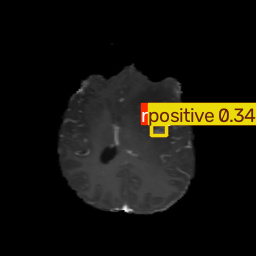

In [29]:
result = results[0]

result.plot()

In [30]:
tumor_detected = False

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = model.names[class_id]

    print(f"Class: {class_name}, Confidence: {confidence:.4f}")

    if class_name == "positive":
        tumor_detected = True

if tumor_detected:
    print("Tumor: DETECTED")
else:
    print("Tumor: NOT DETECTED")

Class: positive, Confidence: 0.3351
Class: negative, Confidence: 0.3131
Tumor: DETECTED


In [31]:
for box in result.boxes:
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    confidence = float(box.conf[0])
    class_id = int(box.cls[0])

    print("Class:", class_id)
    print("Confidence:", confidence)
    print("Bounding Box:")
    print(x1, y1, x2, y2)

Class: 1
Confidence: 0.3350537419319153
Bounding Box:
151.69652 124.48301 166.54524 135.68584
Class: 0
Confidence: 0.31310054659843445
Bounding Box:
151.78545 124.52344 166.4602 135.95103


In [32]:
# Calculate tumor dimensions and area

tumor_box = None

for box in result.boxes:
    class_id = int(box.cls[0])

    if class_id == 1:  # positive = tumor
        tumor_box = box
        break

if tumor_box is not None:

    x1, y1, x2, y2 = tumor_box.xyxy[0].cpu().numpy()

    tumor_width = x2 - x1
    tumor_height = y2 - y1

    tumor_area = tumor_width * tumor_height

    print("Tumor Measurements")
    print("------------------")
    print(f"Width  : {tumor_width:.2f} pixels")
    print(f"Height : {tumor_height:.2f} pixels")
    print(f"Area   : {tumor_area:.2f} pixels²")

else:
    print("No tumor detected.")

Tumor Measurements
------------------
Width  : 14.85 pixels
Height : 11.20 pixels
Area   : 166.35 pixels²


In [36]:
import cv2
import numpy as np

# Get the original image used by YOLO
img = result.orig_img

# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Create a rough brain mask
_, brain_mask = cv2.threshold(
    gray,
    10,
    255,
    cv2.THRESH_BINARY
)

# Calculate brain area
brain_area = cv2.countNonZero(brain_mask)

# Calculate tumor percentage
tumor_percentage = (tumor_area / brain_area) * 100

print("Area Comparison")
print("----------------")
print(f"Brain Area       : {brain_area} pixels²")
print(f"Tumor Area       : {tumor_area:.2f} pixels²")
print(f"Tumor/Brain Area : {tumor_percentage:.4f}%")

Area Comparison
----------------
Brain Area       : 16409 pixels²
Tumor Area       : 166.35 pixels²
Tumor/Brain Area : 1.0138%


In [37]:
# Experimental Severity and Priority

if tumor_percentage < 1:
    severity = "Low"
    priority = "Routine"

elif tumor_percentage < 3:
    severity = "Moderate"
    priority = "Attention"

elif tumor_percentage < 5:
    severity = "High"
    priority = "High"

else:
    severity = "Very High"
    priority = "Urgent"

print("Final Assessment")
print("----------------")
print(f"Tumor Area Percentage : {tumor_percentage:.4f}%")
print(f"Severity              : {severity}")
print(f"Priority              : {priority}")

Final Assessment
----------------
Tumor Area Percentage : 1.0138%
Severity              : Moderate
Priority              : Attention
